## 1. Import bibliotek

In [1]:
# Path ułatwia pracę ze ścieżkami do plików.
from pathlib import Path

# NumPy służy do operacji numerycznych.
import numpy as np

# Pandas służy do wczytywania i analizowania danych tabelarycznych.
import pandas as pd

# Matplotlib i Seaborn służą do tworzenia wykresów.
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow i Keras służą do budowania sieci neuronowej.
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Narzędzia scikit-learn służą do przygotowania i oceny danych.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Ustalamy ziarna losowości, aby wyniki były bardziej powtarzalne.
np.random.seed(42)
tf.random.set_seed(42)

## 2. Wczytanie danych

In [2]:
# Najpierw szukamy pliku iris.csv w folderze z notebookiem.
data_path = Path("iris.csv")

# Jeżeli notebook jest uruchamiany z innego folderu,
# korzystamy ze wskazanej lokalizacji na Pulpicie.
if not data_path.exists():
    data_path = Path(
        r"C:\Users\micha\Desktop\Kodilla_Kurs\Modul18\iris.csv"
    )

# Wczytujemy dane z pliku CSV.
iris = pd.read_csv(data_path)

# Wyświetlamy pierwszych pięć obserwacji.
iris.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [3]:
# Wyświetlamy rozmiar zbioru.
print("Rozmiar zbioru:", iris.shape)

# Sprawdzamy typy kolumn i ewentualne braki danych.
print("\nBraki danych:")
print(iris.isna().sum())

# Sprawdzamy liczbę obserwacji każdego gatunku.
print("\nLiczebność klas:")
print(iris["variety"].value_counts())

Rozmiar zbioru: (150, 5)

Braki danych:
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

Liczebność klas:
variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


Zbiór jest zbalansowany: każdy gatunek ma tyle samo przykładów. Brakujące wartości należałoby uzupełnić albo usunąć przed trenowaniem; w tym pliku nie powinny występować.

## 3. Przygotowanie cech i etykiet

In [4]:
# Wybieramy cztery kolumny numeryczne jako cechy modelu.
feature_names = [
    "sepal.length",
    "sepal.width",
    "petal.length",
    "petal.width"
]

# Tworzymy macierz cech X.
X = iris[feature_names].copy()

# Tworzymy wektor nazw gatunków.
y_text = iris["variety"].copy()

# Zamieniamy nazwy gatunków na liczby całkowite 0, 1 i 2.
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

# Zapamiętujemy nazwy klas w kolejności używanej przez model.
class_names = label_encoder.classes_

# Pokazujemy mapowanie nazw na numery.
class_mapping = pd.DataFrame({
    "Numer klasy": np.arange(len(class_names)),
    "Gatunek": class_names
})
class_mapping

,Numer klasy,Gatunek
0,0,Setosa
1,1,Versicolor
2,2,Virginica


## 4. Podział na zbiory treningowy, walidacyjny i testowy

In [5]:
# Najpierw odkładamy 20% danych jako niezależny zbiór testowy.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Z pozostałych danych wydzielamy zbiór walidacyjny.
# 25% z 80% całego zbioru daje 20% wszystkich obserwacji.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

# Wyświetlamy rozmiary wszystkich zbiorów.
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (90, 4) (90,)
Validation: (30, 4) (30,)
Test: (30, 4) (30,)


Parametr `stratify` zachowuje proporcje klas. Zbiór testowy nie uczestniczy w wyborze modelu — służy dopiero do końcowej oceny.

## 5. Standaryzacja cech

In [6]:
# Tworzymy obiekt standaryzujący dane.
scaler = StandardScaler()

# Dopasowujemy skaler wyłącznie do danych treningowych.
X_train_scaled = scaler.fit_transform(X_train)

# Dane walidacyjne i testowe transformujemy parametrami poznanymi na train.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Sprawdzamy średnie i odchylenia w przeskalowanym zbiorze treningowym.
print("Średnie:", X_train_scaled.mean(axis=0).round(4))
print("Odchylenia standardowe:", X_train_scaled.std(axis=0).round(4))

Średnie: [ 0. -0. -0. -0.]
Odchylenia standardowe: [1. 1. 1. 1.]


Standaryzacja wyrównuje skalę cech. `fit_transform` wykonujemy tylko na zbiorze treningowym, aby uniknąć wycieku informacji ze zbiorów walidacyjnego i testowego.

## 6. Budowa modelu

In [7]:
# Liczba cech wejściowych wynosi cztery.
number_of_features = X_train_scaled.shape[1]

# Liczba klas wynosi trzy.
number_of_classes = len(class_names)

# Budujemy model sekwencyjny.
model = Sequential([

    # Warstwa wejściowa przyjmuje cztery cechy kwiatu.
    Input(shape=(number_of_features,)),

    # Pierwsza warstwa ukryta ma 16 neuronów z funkcją ReLU.
    Dense(
        units=16,
        activation="relu"
    ),

    # Druga, mniejsza warstwa ukryta ma 8 neuronów.
    Dense(
        units=8,
        activation="relu"
    ),

    # Warstwa wyjściowa ma po jednym neuronie dla każdego gatunku.
    # Softmax zamienia wyniki na prawdopodobieństwa sumujące się do 1.
    Dense(
        units=number_of_classes,
        activation="softmax"
    )
])

# Konfigurujemy sposób trenowania.
model.compile(

    # Adam odpowiada za aktualizowanie wag modelu.
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    # Etykiety są liczbami 0–2, dlatego używamy wersji Sparse.
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),

    # Monitorujemy dokładność klasyfikacji.
    metrics=["accuracy"]
)

# Wyświetlamy strukturę i liczbę parametrów modelu.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Trenowanie

In [8]:
# EarlyStopping zatrzyma trening, gdy val_loss przestanie się poprawiać.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Trenujemy model.
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.6333 - loss: 0.9636 - val_accuracy: 0.6667 - val_loss: 0.9127
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6444 - loss: 0.9264 - val_accuracy: 0.6667 - val_loss: 0.8796
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6556 - loss: 0.8916 - val_accuracy: 0.6667 - val_loss: 0.8472
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6556 - loss: 0.8584 - val_accuracy: 0.6667 - val_loss: 0.8159
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6556 - loss: 0.8261 - val_accuracy: 0.6667 - val_loss: 0.7862
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6556 - loss: 0.7954 - val_accuracy: 0.6667 - val_loss: 0.7577
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6667 - loss: 0.7659 - val_accuracy: 0.6667 - val_loss: 0.7307
Epoch 8/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6667 - loss: 0.7375 - val_accuracy: 0.6667 - val_loss

## 8. Przebieg uczenia

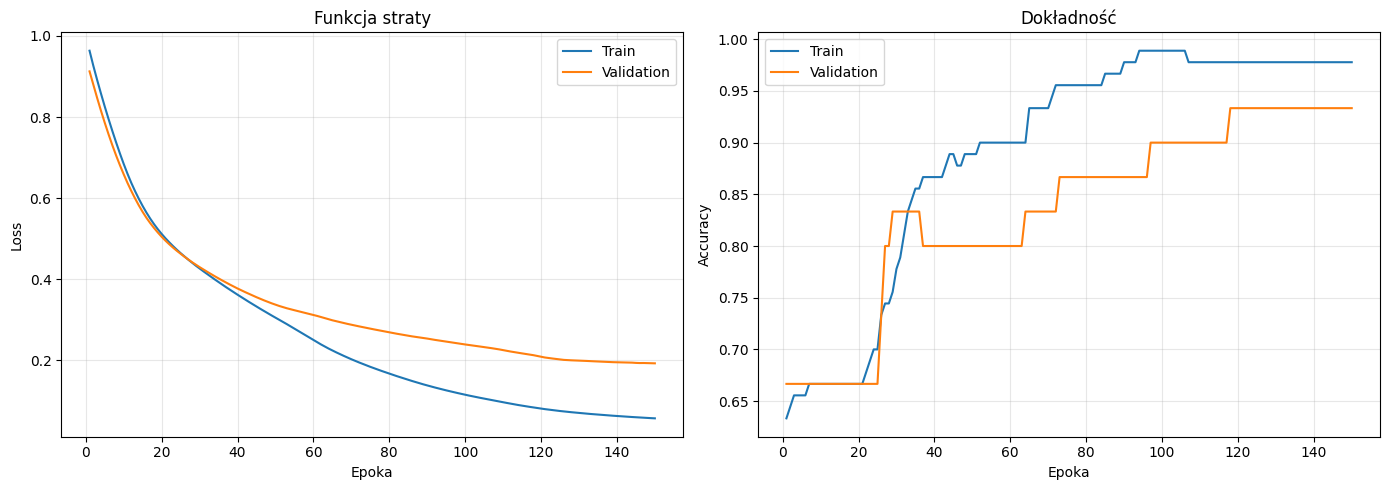

In [9]:
# Pobieramy numery wykonanych epok.
epochs_completed = range(1, len(history.history["loss"]) + 1)

# Tworzymy dwa wykresy obok siebie.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres funkcji straty.
axes[0].plot(epochs_completed, history.history["loss"], label="Train")
axes[0].plot(epochs_completed, history.history["val_loss"], label="Validation")
axes[0].set_title("Funkcja straty")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Wykres dokładności.
axes[1].plot(epochs_completed, history.history["accuracy"], label="Train")
axes[1].plot(
    epochs_completed,
    history.history["val_accuracy"],
    label="Validation"
)
axes[1].set_title("Dokładność")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Dopasowujemy układ i wyświetlamy wykresy.
plt.tight_layout()
plt.show()

## 9. Ocena na zbiorze testowym

In [10]:
# Oceniamy model na danych, których nie widział podczas trenowania.
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

# Wyświetlamy końcowe wyniki.
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.1337
Test accuracy: 0.9333


## 10. Predykcje Softmax

In [11]:
# Model zwraca trzy prawdopodobieństwa dla każdej obserwacji.
y_probabilities = model.predict(
    X_test_scaled,
    verbose=0
)

# Wybieramy klasę o największym prawdopodobieństwie.
y_pred = np.argmax(y_probabilities, axis=1)

# Tworzymy tabelę z przykładowymi predykcjami.
prediction_preview = pd.DataFrame({
    "Prawdziwa klasa": label_encoder.inverse_transform(y_test[:10]),
    "Przewidziana klasa": label_encoder.inverse_transform(y_pred[:10]),
    "Najwyższe prawdopodobieństwo": y_probabilities[:10].max(axis=1)
})

prediction_preview.style.format({
    "Najwyższe prawdopodobieństwo": "{:.2%}"
})

,Prawdziwa klasa,Przewidziana klasa,Najwyższe prawdopodobieństwo
0,Setosa,Setosa,99.92%
1,Virginica,Virginica,91.26%
2,Versicolor,Versicolor,98.80%
3,Versicolor,Versicolor,99.37%
4,Setosa,Setosa,99.95%
5,Versicolor,Versicolor,63.95%
6,Setosa,Setosa,99.98%
7,Setosa,Setosa,99.75%
8,Virginica,Virginica,98.59%
9,Versicolor,Versicolor,79.03%


In [12]:
# Sprawdzamy, czy prawdopodobieństwa każdej obserwacji sumują się do 1.
print(
    "Sumy prawdopodobieństw dla pierwszych pięciu obserwacji:",
    y_probabilities[:5].sum(axis=1).round(4)
)

Sumy prawdopodobieństw dla pierwszych pięciu obserwacji: [1. 1. 1. 1. 1.]


## 11. Raport klasyfikacji i macierz pomyłek

              precision    recall  f1-score   support

      Setosa     1.0000    1.0000    1.0000        10
  Versicolor     0.9000    0.9000    0.9000        10
   Virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30



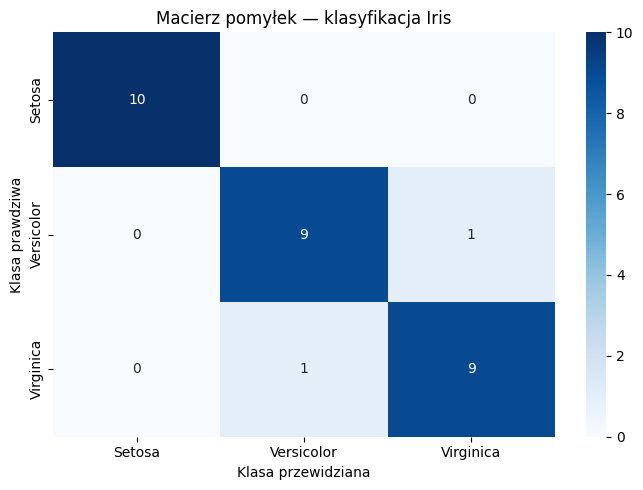

In [13]:
# Wyświetlamy Precision, Recall i F1 osobno dla każdego gatunku.
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4
))

# Obliczamy macierz pomyłek.
cm = confusion_matrix(y_test, y_pred)

# Wizualizujemy macierz pomyłek.
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Macierz pomyłek — klasyfikacja Iris")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa prawdziwa")
plt.tight_layout()
plt.show()

## Wnioski

Zbudowana sieć neuronowa skutecznie klasyfikuje trzy gatunki kwiatów Iris. Model osiągnął dokładność 93,33% na zbiorze testowym, poprawnie rozpoznając 28 z 30 obserwacji. Gatunek Setosa został sklasyfikowany bezbłędnie, natomiast pojedyncze pomyłki wystąpiły między gatunkami Versicolor i Virginica, których cechy są bardziej zbliżone. Podobne wyniki na zbiorze walidacyjnym i testowym wskazują, że model dobrze generalizuje i nie wykazuje wyraźnego przeuczenia.